In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

def set_size_square(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions for square subplots to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    # Figure height in inches, calculated to make subplots square
    # The height of the total figure is the width multiplied by the ratio of rows to columns.
    fig_height_in = fig_width_in * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

# import matplotlib as mpl
# mpl.use('pgf')
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Define the custom tikz style string
tikz_outlined_arrow = r"""
\tikzset{%
% use: outlinedArrow={inner color}{inner width}{outline color}{outine width}{arrowhead length scale}{tip angle}
    outlinedArrow/.style n args={6}{%,
        arrows={-Stealth[bend,
            % see linkd man page for full info
            %   https://tikz.dev/tikz-arrows#pgf./pgf/arrow:keys/length
            length= % the sum of the below
                % dimension
                #5*#2
                % line width factor
                1/2*(cosec(#6/2)+cot(atan(tan(#6/2)/0.325))*sec(#6)/(1-0.325)+0.325*cot(#6/2)*sqrt(1+(tan(#6/2)^2)/(0.325^2)))
                % outer factor
                -#2/2*(cosec(#6/2)+cot(atan(tan(#6/2)/0.325))*sec(#6)/(1-0.325)+0.325*cot(#6/2)*sqrt(1+(tan(#6/2)^2)/(0.325^2))),
            % explicit
            inset'=0pt 0.325, % explicitly call the default inset' arg per manual - used as const above
            angle'=#6]},
        line width=#2+2*#4,
        draw=#3,
        color=#3,
        postaction={
            draw=#1,
            color=#1,
            line width=#2,
            shorten >=cosec(#6/2)*#4,
            shorten <=#4,
        },
        outlinedArrow/.default={gray}{0.4pt}{black}{0.4pt}{8}{30},
        outlinedArrow/.initial={gray}{0.4pt}{black}{0.4pt}{8}{30},
    }
}
"""

# Update matplotlib settings
plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True, # Enable TeX rendering
    "pgf.rcfonts": False,
    "pgf.preamble": "\n".join([
        r"\usepackage[T1]{fontenc}",
        r"\usepackage[utf8]{inputenc}",
        r"\usepackage{amsmath}",
        r"\usepackage{amsfonts}",
        r"\usepackage{siunitx}",
        r"\ifdefined\qty\else\newcommand{\qty}[2]{\SI{#1}{#2}}\fi", 
        r"\ifdefined\unit\else\newcommand{\unit}[1]{\si{#1}}\fi",
        r"\usepackage{amssymb}",
        r"\usepackage{xcolor}",
        r"\usepackage{tikz}",
        r"\usetikzlibrary{arrows.meta}",
        r"\usetikzlibrary{bending}",
        r"\def\mathdefault#1{#1}",
        r"\usepackage[outline]{contour}",
        tikz_outlined_arrow
    ])
})
plt.rcParams['font.size'] = 12
# The amsmath package is needed for \text{}, fontenc is for font encoding
# Fix the LaTeX preamble to define mathdefault and include necessary packages
# Also including tikz_outlined_arrow here for standard text.latex.preamble usage
plt.rcParams["text.latex.preamble"] = r"""
\usepackage[T1]{fontenc}
\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{siunitx}
\ifdefined\qty\else\newcommand{\qty}[2]{\SI{#1}{#2}}\fi
\ifdefined\unit\else\newcommand{\unit}[1]{\si{#1}}\fi
\usepackage{amssymb}
\usepackage{xcolor}
\usepackage{tikz}
\usetikzlibrary{arrows.meta}
\usetikzlibrary{bending}
\def\mathdefault#1{#1}
\usepackage[outline]{contour}
""" + tikz_outlined_arrow

def sci_tex(val, sig=3):
    """
    Format number with sig significant figures as LaTeX 'a×10^{b}' (no $ added).
    Falls back to plain number if no exponent.
    """
    s = f"{val:.{sig}g}"
    if 'e' in s or 'E' in s:
        base, exp = s.lower().split('e')
        exp_int = int(exp)  # handles +00, -03, etc.
        return rf"{base}\times 10^{{{exp_int}}}"
    return s

doc_size=441.01773

In [3]:
from collections import defaultdict

def parse_histogram_data(filepath):
    """
    Parse txt file to extract histogram data from analysis software output.
    Looks for entries: "Equivalent radius [particle/total]\tvalue\tunit\tframe\tfilename"
    """
    histograms = defaultdict(lambda: {'sizes': [], 'unit': ''})
    
    # Try different encodings to handle various file formats
    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
    content = None
    
    for encoding in encodings:
        try:
            with open(filepath, 'r', encoding=encoding) as f:
                content = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if content is None:
        # If all encodings fail, read with errors='ignore'
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
    
    # Pattern: Equivalent radius [particle/total]\tvalue\tunit\tframe\tfilename
    # More flexible pattern to capture data across lines
    pattern = r'Equivalent radius\s+\[\d+/\d+\]\s+([\d.]+)\s+(\S+)\s+(\d+)\s+(.+?)(?:\n|$)'
    
    matches = re.findall(pattern, content, re.MULTILINE)
    
    for match in matches:
        size, unit, frame, filename = match
        filename = filename.strip()
        
        # Convert size to nm
        size_float = float(size)
        if unit.strip() == 'µm' or unit.strip() == 'um':
            size_float *= 1000  # Convert µm to nm
            unit = 'nm'
        
        histograms[filename]['sizes'].append(size_float)
        histograms[filename]['unit'] = unit
    
    return dict(histograms)


def get_time_label(filename):
    """
    Map filename to time label based on sample number.
    1.1: 60 min, 1.2: 48 min, 1.3: 36 min, 1.4: 28 min, 1.6: 12 min
    """
    time_map = {
        '1.1': '60 min',
        '1.2': '48 min',
        '1.3': '36 min',
        '1.4': '28 min',
        '1.6': '12 min'
    }
    
    for key, time_val in time_map.items():
        if key in filename:
            return time_val
    
    return filename  # Return original if no match


def plot_histograms(histograms):
    """
    Plot each histogram individually with filename as title.
    Overlays skew-normal distribution fit with colors from colormap.
    Y-axis shows percentage values (0-100) by multiplying density by 100.
    """
    from scipy.stats import skewnorm
    from matplotlib.ticker import FuncFormatter
    
    # Get colormap and number of histograms
    cmap = plt.get_cmap('tab20b')
    hist_items = list(histograms.items())
    n_hists = len(hist_items)
    
    for idx, (filename, data) in enumerate(hist_items):
        sizes = np.array(data['sizes'])
        
        if len(sizes) == 0:
            print(f"Skipping {filename} - no data points")
            continue
        
        # Get time label for title
        time_label = get_time_label(filename)
        
        # Get color for this histogram
        bar_color = cmap(idx / max(n_hists - 1, 1))
        
        # Create figure
        fig, ax = plt.subplots(figsize=set_size(doc_size))
        
        # Compute density histogram and convert to percentage (multiply by 100)
        counts, bins = np.histogram(sizes, bins='auto', density=True)
        bin_widths = np.diff(bins)
        heights = counts * 100  # convert density to percentage units
        ax.bar(bins[:-1], heights, width=bin_widths, color=bar_color, alpha=0.7, edgecolor='black', align='edge')
        
        # Fit skew-normal distribution and plot (convert to percentage)
        a, loc, scale = skewnorm.fit(sizes)
        x_fit = np.linspace(np.min(sizes), np.max(sizes), 200)
        y_fit = skewnorm.pdf(x_fit, a, loc=loc, scale=scale) * 100
        ax.plot(x_fit, y_fit, color='black', linestyle='--', linewidth=2,
                label=f'$\\mu={loc:.1f},\\,\\sigma={scale:.1f},\\,\\alpha={a:.2f}$')
        
        # Set title and labels
        ax.set_title(f'{time_label}')
        ax.set_xlabel(f'Size [nm]')
        ax.set_ylabel(r'Frequency [$\%$]')
        ax.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()


# Parse your particle.txt file
filepath = "AFM/Time Series/PnP Analysis/particle.txt"
histograms = parse_histogram_data(filepath)

# Print summary
print(f"Found {len(histograms)} histograms:")
for filename, data in histograms.items():
    time_label = get_time_label(filename)
    print(f"  {time_label}: {len(data['sizes'])} particles, unit: {data['unit']}")

# # Plot all histograms
# plot_histograms(histograms)


Found 5 histograms:
  60 min: 89 particles, unit: nm
  48 min: 8482 particles, unit: nm
  36 min: 7569 particles, unit: nm
  28 min: 7895 particles, unit: nm
  12 min: 9056 particles, unit: nm


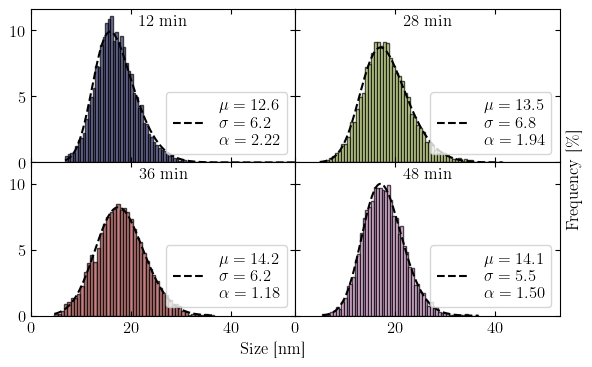

In [ ]:
def plot_histograms_grid(histograms, exclude_time='60 min'):
    """
    Plot histograms in a 2x2 grid, sharing both x and y axes.
    Axis labels shown only once. Titles inside the plot.
    """
    from scipy.stats import skewnorm

    items = [(fn, d) for fn, d in histograms.items()
             if get_time_label(fn) != exclude_time and len(d['sizes']) > 0]

    time_order = {'12 min': 0, '28 min': 1, '36 min': 2, '48 min': 3}
    items.sort(key=lambda x: time_order.get(get_time_label(x[0]), 99))


    n_rows, n_cols = 2, 2
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=set_size(doc_size, fraction=1, subplots=(n_rows, n_cols)),
                             sharey=True, sharex=True)
    axes_flat = axes.ravel()

    fig.subplots_adjust(wspace=0, hspace=0)

    cmap = plt.get_cmap('tab20b')
    n = len(items)

    for idx, (filename, data) in enumerate(items):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        sizes = np.array(data['sizes'])
        color = cmap(idx / max(n - 1, 1))
        time_label = get_time_label(filename)

        counts, bins_used = np.histogram(sizes, bins='auto', density=True)
        widths = np.diff(bins_used)
        heights = counts * 100
        ax.bar(bins_used[:-1], heights, width=widths, color=color,
               alpha=0.7, edgecolor='black', align='edge')

        # Fit skew-normal distribution and plot (convert to percentage)
        a, loc, scale = skewnorm.fit(sizes)
        x_fit = np.linspace(np.min(sizes), np.max(sizes), 200)
        y_fit = skewnorm.pdf(x_fit, a, loc=loc, scale=scale) * 100
        ax.plot(x_fit, y_fit, color='black', linestyle='--', linewidth=1.5,
                label=f'$\\mu={loc:.1f}$ \n $\\sigma={scale:.1f}$ \n $\\alpha={a:.2f}$')

        # Title inside the plot (top-centre)
        ax.text(0.5, 0.97, time_label, transform=ax.transAxes,
                ha='center', va='top', fontsize='medium',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

        ax.legend(loc='lower right')

        col = idx % n_cols
        row = idx // n_cols

        # Y ticks: only left column shows labels; right column has inward ticks only
        if col == 0:
            ax.tick_params(axis='y', which='both', direction='in',
                           left=True, right=True, labelleft=True, labelright=False)
            ax.spines['right'].set_visible(True)
        else:
            ax.tick_params(axis='y', which='both', direction='in',
                           left=True, right=True, labelleft=False, labelright=False)
            # ax.spines['left'].set_visible(False)

        # X ticks: only bottom row shows labels; top row has inward ticks only
        if row == n_rows - 1:
            ax.tick_params(axis='x', which='both', direction='in',
                           bottom=True, top=True, labelbottom=True, labeltop=False)
        else:
            ax.tick_params(axis='x', which='both', direction='in',
                           bottom=True, top=True, labelbottom=False, labeltop=False)
            # ax.spines['bottom'].set_visible(False)

    for idx in range(len(items), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # Single shared axis labels
    fig.text(0.5, 0.03, 'Size [nm]', ha='center', va='bottom')
    fig.text(0, 0.5, r'Frequency [$\%$]', ha='left', va='center', rotation='vertical')
    plt.xlim(0,53)
    
    fig.tight_layout(rect=(0.04, 0.04, 1, 1))
    fig.subplots_adjust(wspace=0, hspace=0)
    plt.savefig('Histogrampgf/histogram.pgf', format='pgf', bbox_inches='tight')
    plt.show()

plot_histograms_grid(histograms)
